# Results: the classics against the alternatives

The comparison this project exists to make. Every model is fitted on the 2020
cohort and scored on the 2021 cohort — strictly out of time, with all
preprocessing (winsorising cut-points, imputation medians, category levels,
quintile thresholds) learned inside the fitting pipeline so that nothing about
the test year leaks backwards.

Two expensive artefacts — the paired bootstrap and the permutation importances —
are read from `outputs/tables`, produced by `python -m charity_risk.pipeline`.
Everything else is computed here.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import average_precision_score, roc_auc_score

from charity_risk import config, plots
from charity_risk.dataset import load_dataset, exit_split, scoring_frame
from charity_risk.evaluate import (
    bootstrap_metric_difference, calibration_table, compare_models, fit_all,
    lift_table,
)
from charity_risk.models import CURVE_SPECIFICATIONS, SPECIFICATIONS

plots.use_project_style()
pd.set_option("display.width", 220)

columns = sorted({c for spec in SPECIFICATIONS.values() for c in spec.columns}) + [
    "exit_next_year", "legal_name", "total_revenue", "total_assets", "net_assets"]
frame = load_dataset(years=[config.TRAIN_YEAR, config.TEST_YEAR, config.SCORE_YEAR],
                     columns=columns)
train, test = exit_split(frame)

pd.DataFrame({
    "specification": {k: s.label for k, s in SPECIFICATIONS.items()},
    "source": {k: s.citation for k, s in SPECIFICATIONS.items()},
    "n_features": {k: len(s.columns) for k, s in SPECIFICATIONS.items()},
})

,specification,source,n_features
size_only,Size only (log revenue),Null benchmark: how much of the classics is ju...,1
tuckman_chang_1991,Tuckman-Chang score (0-4),Tuckman & Chang (1991),4
hs_index_flags,HS index (flags),HS index; this project,12
hs_index,HS index (percentile),HS index; this project,12
greenlee_trussel_2000,Greenlee-Trussel logit (4 TC ratios),Greenlee & Trussel (2000),4
trussel_2002,Trussel logit (ratios + size + sector),Trussel (2002),6
extended_logit,Elastic-net logit (extended),This project,57
gradient_boosting,Gradient boosting (extended),This project,57
deep_neural_net,Deep neural net (extended),"Alam, Gao & Jones (2021)",57
ensemble_blend,Model-average ensemble (logit + GBM + net),Bates & Granger (1969); this project,57


## Model specifications, formally

Every model below has already had a prose treatment — in this notebook and in
`00-literature-review` / `02-features-and-benchmarks` / `06-hs-risk-index`. This
section adds the
formal statement each family corresponds to, for readers who want to know
exactly what estimator produced a number, followed by one plain-language line
for readers who do not need the equation. $x_i$ is charity $i$'s feature
vector; $y_i \in \{0,1\}$ is `exit_next_year`.

**Tuckman-Chang score.** Not a fitted model — a checklist:
$$S_i = \sum_{k=1}^{4} \mathbb{1}\!\left[r_{k,i} \text{ in the sector's risky quintile of ratio } k\right]$$
with each ratio's quintile cut-point estimated on the training sample and
applied unchanged. *In plain terms:* flag an organisation on a ratio if it
sits in the worst fifth of the sector on that ratio, and count the flags.

**HS risk index.** Also not a fitted model, and a separate index from the
Tuckman-Chang score: twelve ratios $k$ grouped into five dimensions $j$
(solvency, liquidity, profitability, efficiency, revenue),
$$s_{k,i} = \hat F_k(d_k\, r_{k,i}), \qquad D_{j,i} = \operatorname{mean}_{k \in j}\, s_{k,i}, \qquad I_i = \operatorname{mean}_{j}\, D_{j,i}$$
where $d_k = \pm 1$ orients ratio $k$ so that larger is riskier, $\hat F_k$ is
its empirical CDF in the training sample, and each mean runs over the ratios
and dimensions observed for charity $i$. The flag form replaces $s_{k,i}$ with
an indicator for the ratio's riskiest fifth. A one-variable logit maps $I_i$ to
a probability so it can be scored on the same metrics; being monotone, it
changes no ranking. *In plain terms:* for each ratio, take the share of last
year's sector that looked safer; average those within each dimension, then
average the dimensions, so each of the five counts equally however many ratios
describe it. `06-hs-risk-index` builds and evaluates it in full.

**Greenlee-Trussel (2000), Trussel (2002), size-only, elastic-net logit.** All
four are the same functional form,
$$\Pr(y_i = 1 \mid x_i) = \sigma(\beta_0 + \beta^\top x_i), \qquad \sigma(z) = \frac{1}{1+e^{-z}}$$
differing only in which $x_i$ go in and how $\beta$ is estimated: maximum
likelihood for the first three (4, 6 and 1 predictors respectively), and
elastic-net-penalised maximum likelihood —
$\min_\beta -\ell(\beta) + \tfrac{1}{C}\left[\tfrac{1-\rho}{2}\lVert\beta\rVert_2^2 + \rho\lVert\beta\rVert_1\right]$
— for the 57-feature version, where the penalty keeps the fit stable on
correlated ratios an unpenalised fit would not handle. *In plain terms:* each
feature gets a weight, the weighted sum is squashed into a probability, and
the weights are chosen to make the observed exits as likely as possible.

**Gradient boosting.** An additive expansion of shallow decision trees, fitted
one at a time on the current model's error:
$$F_M(x) = \sum_{m=1}^{M} \nu\, h_m(x), \qquad h_m = \arg\min_h \sum_i \ell\bigl(y_i,\, F_{m-1}(x_i) + h(x_i)\bigr)$$
*In plain terms:* a sequence of simple decision rules, each correcting what
the rules before it got wrong, added together into a score. Every split is a
threshold test on one feature, so — unlike the logits above — it can find a
breakpoint (interest coverage below 1x, say) without being told where to look.

**Deep neural net.** A composition of affine transformations and a fixed
nonlinearity $\phi$ (ReLU), three hidden layers wide,
$$\hat p_i = \sigma\bigl(W_4\,\phi(W_3\,\phi(W_2\,\phi(W_1 x_i + b_1) + b_2) + b_3) + b_4\bigr)$$
fitted jointly by minimising binomial cross-entropy with Adam. *In plain
terms:* the same logistic-regression idea, but the weighted sum passes through
several rounds of learned, nonlinear recombination before becoming a
probability, so it can represent interactions the logit's single linear
combination cannot.

**Model-average ensemble.** No new functional form — a forecast combination
({cite:t}`bates1969`) of the three models above it:
$$\hat p_i = \tfrac{1}{3}\bigl(\hat p_i^{\text{logit}} + \hat p_i^{\text{gbm}} + \hat p_i^{\text{mlp}}\bigr)$$
*In plain terms:* average the risk score three different modelling approaches
assign, on the logic that models making different kinds of mistakes partly
cancel each other's mistakes out when combined.

**Hierarchical logit.** Introduced separately, below, once the flat comparison
is done — see its own formal statement there.

In [2]:
fitted = fit_all(train, "exit_next_year")
results = compare_models(fitted, test, "exit_next_year")

headline = results[["label", "roc_auc", "average_precision", "brier_skill",
                    "lift_top1pct", "lift_top5pct", "recall_top5pct",
                    "calibration_slope"]]
headline.style.format({
    "roc_auc": "{:.3f}", "average_precision": "{:.3f}", "brier_skill": "{:.3f}",
    "lift_top1pct": "{:.1f}x", "lift_top5pct": "{:.1f}x",
    "recall_top5pct": "{:.1%}", "calibration_slope": "{:.2f}",
}).background_gradient(subset=["average_precision"], cmap="Blues")

hs_index_flags: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


HS index: ratios entirely missing in the training sample are not scored: ['revenue_growth_volatility']


hs_index: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


HS index: ratios entirely missing in the training sample are not scored: ['revenue_growth_volatility']


extended_logit: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


gradient_boosting: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


deep_neural_net: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


ensemble_blend: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


,label,roc_auc,average_precision,brier_skill,lift_top1pct,lift_top5pct,recall_top5pct,calibration_slope
model,,,,,,,,
ensemble_blend,Model-average ensemble (logit + GBM + net),0.840,0.196,0.096,16.0x,8.2x,41.2%,0.93
gradient_boosting,Gradient boosting (extended),0.844,0.193,0.096,17.2x,8.1x,40.6%,0.83
deep_neural_net,Deep neural net (extended),0.820,0.171,0.066,13.0x,7.8x,39.0%,0.83
extended_logit,Elastic-net logit (extended),0.828,0.157,0.075,12.7x,7.7x,38.7%,0.88
trussel_2002,Trussel logit (ratios + size + sector),0.807,0.111,0.052,9.2x,7.1x,35.4%,0.91
greenlee_trussel_2000,Greenlee-Trussel logit (4 TC ratios),0.744,0.094,0.045,9.1x,6.7x,33.5%,0.96
size_only,Size only (log revenue),0.786,0.081,0.036,5.9x,5.6x,28.0%,0.97
hs_index,HS index (percentile),0.665,0.049,0.011,5.8x,3.2x,16.0%,0.92
hs_index_flags,HS index (flags),0.614,0.040,0.007,4.7x,3.0x,15.2%,0.89


## How to read this table

The exit base rate is 2.0%, so accuracy is meaningless and ROC-AUC is
optimistic — it is dominated by the vast easy majority of true negatives. Two
columns carry the weight:

* **Average precision** — area under the precision-recall curve. At a 2% base
  rate a no-skill model scores 0.020.
* **Lift in the top 1% / 5%** — the honest operational number. A supervisor with
  the budget to review 5% of the register wants to know how many more failures
  that 5% contains than a random 5% would.

**Calibration slope** is reported separately because it answers a different
question. A slope below 1 means the score is over-dispersed: useful for ranking,
but the probabilities themselves should not be plugged into expected-loss
arithmetic without recalibration.

The table also carries both forms of the HS risk index, flags and percentile.
"Where the HS index lands", below, sets them against the benchmarks they are
most naturally compared with.

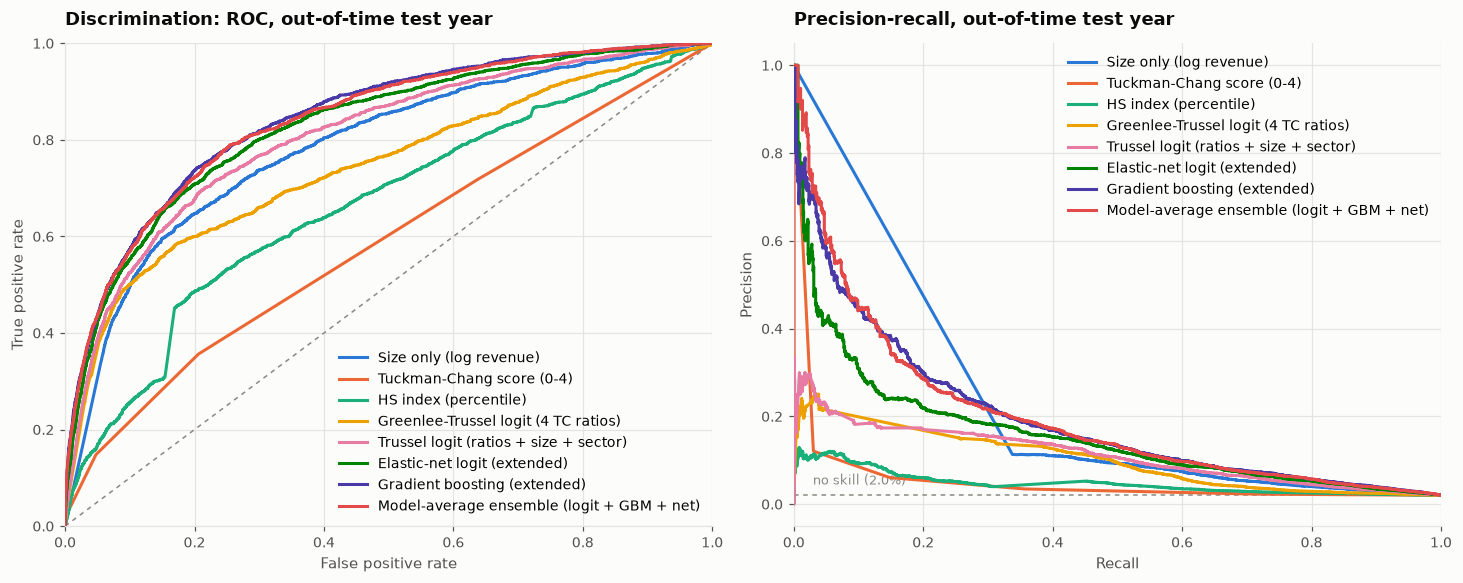

In [3]:
y_test = test["exit_next_year"].to_numpy()
risks = {model.spec.label: model.risk(test) for model in fitted.values()}
# Eight colour slots, ten specifications: the curves leave out the deep net and
# the flag form of the HS index. The tables carry all ten.
chart_risks = {fitted[k].spec.label: risks[fitted[k].spec.label] for k in CURVE_SPECIFICATIONS}

fig, axes = plots.plt.subplots(1, 2, figsize=(13.4, 5.4))
plots.plot_roc_curves(y_test, chart_risks, ax=axes[0])
plots.plot_pr_curves(y_test, chart_risks, ax=axes[1])
fig.tight_layout();

The two panels tell different stories, and the difference is the point.

On ROC, everything except the two unfitted indices (the Tuckman-Chang count and
the HS index) looks broadly similar: the classical logits land within 0.10 of
gradient boosting. On precision-recall, gradient boosting and the ensemble hold
a visible margin over the others across the whole range a screening tool would
operate in, and the two classical logits converge toward the no-skill line well
before they do. ROC flatters models on imbalanced problems; a supervisor choosing
a screening tool on AUC alone would materially over-value the classics.

The palette has eight colour slots and the table ten models, so the curves
leave out two: the deep net, discussed in its own section below, and the flag
form of the HS index, whose percentile form (drawn here) is the one meant for
ranking.

The size-only baseline is the curiosity. Its precision-recall curve is a near
straight line falling from (0, 1.0): log revenue is a coarse, heavily-tied
ranking, so precision degrades linearly as the threshold sweeps down. It reaches
an AUC of 0.786, higher than Greenlee-Trussel's 0.744, on one variable.

## Screening yield

The chart to look at if the model will be used to allocate review capacity. The
x-axis is workload; the y-axis is what that workload catches.

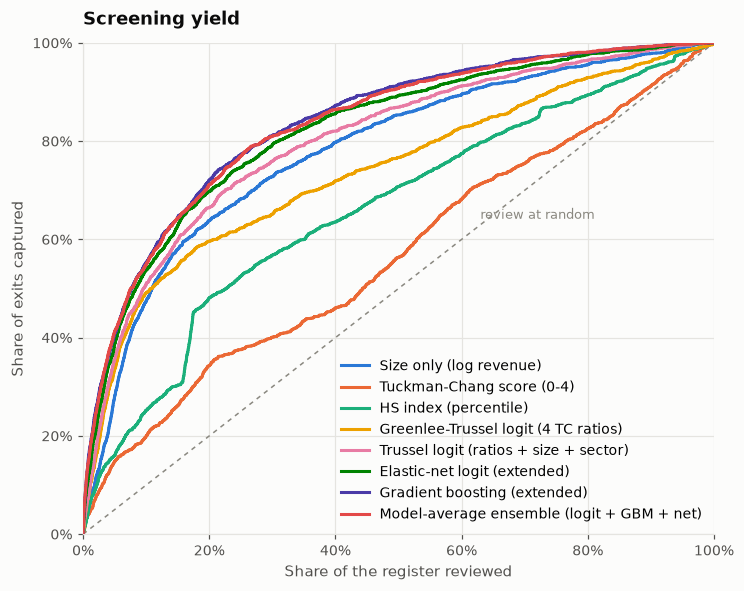

In [4]:
fig, ax = plots.plt.subplots(figsize=(7.4, 5.8))
plots.plot_gains_curves(y_test, chart_risks, ax=ax);

In [5]:
budget = pd.DataFrame({
    label: {
        f"review {int(f*100)}% of register":
            float(np.sum(y_test[np.argsort(-risk, kind='mergesort')][:int(round(f * len(y_test)))]) / y_test.sum())
        for f in (0.01, 0.05, 0.10, 0.25)
    } for label, risk in risks.items()
}).T
budget.style.format("{:.1%}").background_gradient(cmap="Blues")

,review 1% of register,review 5% of register,review 10% of register,review 25% of register
Size only (log revenue),5.9%,28.0%,47.4%,68.3%
Tuckman-Chang score (0-4),4.3%,14.8%,20.0%,37.6%
HS index (flags),4.8%,15.2%,24.5%,44.9%
HS index (percentile),5.8%,16.0%,25.2%,52.5%
Greenlee-Trussel logit (4 TC ratios),8.7%,33.4%,49.2%,62.3%
Trussel logit (ratios + size + sector),9.2%,35.4%,50.9%,72.0%
Elastic-net logit (extended),12.7%,38.7%,53.8%,74.7%
Gradient boosting (extended),17.2%,40.6%,55.3%,77.3%
Deep neural net (extended),13.0%,39.0%,53.4%,73.5%
Model-average ensemble (logit + GBM + net),16.0%,41.2%,54.9%,77.0%


Reviewing the highest-risk 5% of the register, about 4,200 organisations,
catches 41% of the following year's exits under the ensemble or gradient
boosting, 35% under Trussel (2002), 33% under Greenlee-Trussel, 16% under the
HS index and 15% under the Tuckman-Chang count. Reviewing 5% at random catches
5%.

The same thing framed as workload, the share of the register you must review to
catch half of the exits:

In [6]:
def workload_for(risk, target=0.5):
    captured = np.cumsum(y_test[np.argsort(-risk, kind="mergesort")]) / y_test.sum()
    return float(np.argmax(captured >= target) + 1) / len(y_test)

pd.Series({label: workload_for(risk) for label, risk in risks.items()},
          name="share of register reviewed to capture 50% of exits").sort_values().to_frame().style.format("{:.1%}")

,share of register reviewed to capture 50% of exits
Model-average ensemble (logit + GBM + net),7.5%
Gradient boosting (extended),7.7%
Elastic-net logit (extended),8.3%
Deep neural net (extended),8.6%
Trussel logit (ratios + size + sector),9.6%
Greenlee-Trussel logit (4 TC ratios),10.7%
Size only (log revenue),10.9%
HS index (percentile),22.6%
HS index (flags),29.0%
Tuckman-Chang score (0-4),44.3%


## Is the difference real?

Paired bootstrap of the AUC difference against the strongest classical
benchmark, Trussel (2002). Resampling is paired — the same resampled rows score
both models — so the interval reflects the difference rather than the sum of two
independent sampling errors.

In [7]:
bootstrap = pd.read_csv(config.TABLE_DIR / "exit_auc_vs_benchmark.csv", index_col=0)
bootstrap["95% interval"] = bootstrap.apply(
    lambda r: f"[{r['ci_low']:+.3f}, {r['ci_high']:+.3f}]", axis=1)
bootstrap[["label", "versus", "auc_difference", "95% interval", "p_worse"]].round(4)

,label,versus,auc_difference,95% interval,p_worse
model,,,,,
size_only,Size only (log revenue),Trussel logit (ratios + size + sector),-0.0214,"[-0.030, -0.014]",1.0
tuckman_chang_1991,Tuckman-Chang score (0-4),Trussel logit (ratios + size + sector),-0.2201,"[-0.237, -0.206]",1.0
hs_index_flags,HS index (flags),Trussel logit (ratios + size + sector),-0.1929,"[-0.210, -0.178]",1.0
hs_index,HS index (percentile),Trussel logit (ratios + size + sector),-0.1424,"[-0.158, -0.131]",1.0
greenlee_trussel_2000,Greenlee-Trussel logit (4 TC ratios),Trussel logit (ratios + size + sector),-0.0635,"[-0.072, -0.054]",1.0
extended_logit,Elastic-net logit (extended),Trussel logit (ratios + size + sector),0.0210,"[+0.016, +0.026]",0.0
gradient_boosting,Gradient boosting (extended),Trussel logit (ratios + size + sector),0.0368,"[+0.031, +0.043]",0.0
deep_neural_net,Deep neural net (extended),Trussel logit (ratios + size + sector),0.0133,"[+0.007, +0.020]",0.0
ensemble_blend,Model-average ensemble (logit + GBM + net),Trussel logit (ratios + size + sector),0.0333,"[+0.028, +0.039]",0.0


Gradient boosting, the ensemble, the elastic-net logit and the deep net all
beat Trussel (2002) with intervals clear of zero. Greenlee-Trussel (2000) and
the Tuckman-Chang count both lose to it decisively: the 2002 re-specification
was a genuine improvement, and our data reproduces that ordering independently.

The size-only baseline loses to Trussel (2002) by 0.021 AUC. One variable gets
within 3% of a four-ratio model with sector fixed effects.

## Where the HS index lands

The table at the top carries both forms of the HS risk index
(`06-hs-risk-index`), and the percentile form is drawn in the curves above.
Besides the Tuckman-Chang count it is the only score in the comparison with no
fitted weight, and it answers three questions, one per benchmark group:

* **Against the Tuckman-Chang count**, the other unfitted index. Both place
  each ratio against the training-year sector, and they share four ratios. The
  HS index adds eight more, groups all twelve into five equally weighted
  dimensions, and keeps a continuous score; the gap between the two is what
  those choices are worth.
* **Against size alone and the two classical logits**: whether a score with no
  fitted weight can rank exits as well as one variable, or as four ratios
  weighted by maximum likelihood.
* **Against gradient boosting**: the price of transparency, or how much
  ranking a fully decomposable score gives up against the best single fitted
  model.

In [8]:
hs_keys = ["hs_index", "hs_index_flags"]
transparent = ["size_only", "tuckman_chang_1991", "greenlee_trussel_2000", "trussel_2002"]
results.loc[hs_keys + transparent + ["gradient_boosting"],
            ["label", "roc_auc", "average_precision", "lift_top1pct",
             "lift_top5pct", "recall_top5pct", "calibration_slope"]].round(3)

,label,roc_auc,average_precision,lift_top1pct,lift_top5pct,recall_top5pct,calibration_slope
model,,,,,,,
hs_index,HS index (percentile),0.665,0.049,5.758,3.198,0.160,0.917
hs_index_flags,HS index (flags),0.614,0.040,4.711,3.046,0.152,0.886
size_only,Size only (log revenue),0.786,0.081,5.875,5.605,0.280,0.968
tuckman_chang_1991,Tuckman-Chang score (0-4),0.587,0.032,4.246,2.977,0.149,0.935
greenlee_trussel_2000,Greenlee-Trussel logit (4 TC ratios),0.744,0.094,9.074,6.698,0.335,0.958
trussel_2002,Trussel logit (ratios + size + sector),0.807,0.111,9.248,7.081,0.354,0.908
gradient_boosting,Gradient boosting (extended),0.844,0.193,17.159,8.128,0.406,0.831


Paired bootstraps of the percentile form, the one meant for ranking, against
one benchmark from each group, on both ranking metrics.

In [9]:
hs_risk = fitted["hs_index"].risk(test)
rows = []
for versus in ["tuckman_chang_1991", "trussel_2002", "gradient_boosting"]:
    for metric_name, metric in [("roc_auc", roc_auc_score),
                                ("average_precision", average_precision_score)]:
        stats = bootstrap_metric_difference(y_test, hs_risk, fitted[versus].risk(test),
                                            metric=metric, n_boot=500)
        rows.append({"HS index versus": fitted[versus].spec.label,
                     "metric": metric_name, **stats})
pd.DataFrame(rows)[["HS index versus", "metric", "difference", "ci_low",
                    "ci_high", "p_worse"]].round(4)

,HS index versus,metric,difference,ci_low,ci_high,p_worse
0,Tuckman-Chang score (0-4),roc_auc,0.0777,0.0613,0.0931,0.0
1,Tuckman-Chang score (0-4),average_precision,0.0166,0.0129,0.0208,0.0
2,Trussel logit (ratios + size + sector),roc_auc,-0.1424,-0.1584,-0.1306,1.0
3,Trussel logit (ratios + size + sector),average_precision,-0.0628,-0.0728,-0.0533,1.0
4,Gradient boosting (extended),roc_auc,-0.1792,-0.1940,-0.1676,1.0
5,Gradient boosting (extended),average_precision,-0.1442,-0.1620,-0.1275,1.0


**The HS index is a clear improvement on the Tuckman-Chang count, and well
short of everything fitted.** Against the count it gains 0.078 AUC (0.665 against
0.587) and 0.017 average precision (0.049 against 0.032), both with intervals
well clear of zero. The flag form sits between the two (AUC 0.614), so part of
the gain is the extra ratios and dimensions and part is keeping a continuous
score instead of a count.

The gain is not at the very top of the ranking. Reviewing the riskiest 5% of the
register catches 16% of exits under the HS index against 15% under the count;
the difference opens up further down, where the count runs out of distinctions.
Catching half of all exits takes a review of 22.6% of the register under the HS
index, against 44.3% under the count.

Against the fitted benchmarks the gap runs the other way. Size alone beats the
index on every ranking metric except top-1% lift, where the two are level
(5.9x and 5.8x). Trussel (2002) is ahead by 0.142 AUC and 0.063 average
precision, and gradient boosting by 0.179 and 0.144: the index's average
precision is about a quarter of gradient boosting's. That gap is the price of a
score with no fitted weight and no size control.

Two specification choices bound what the index can do on this outcome, and
neither is tuned away here. Its efficiency dimension treats a *low*
administrative cost ratio as risky, the tail `02-features-and-benchmarks`
finds runs the wrong way on exit. Its revenue dimension is scored on
concentration alone, because revenue volatility has no values in the 2020
training year. `06-hs-risk-index` measures the first and explains the second;
the rows above test the index as specified.

## Calibration and decile behaviour

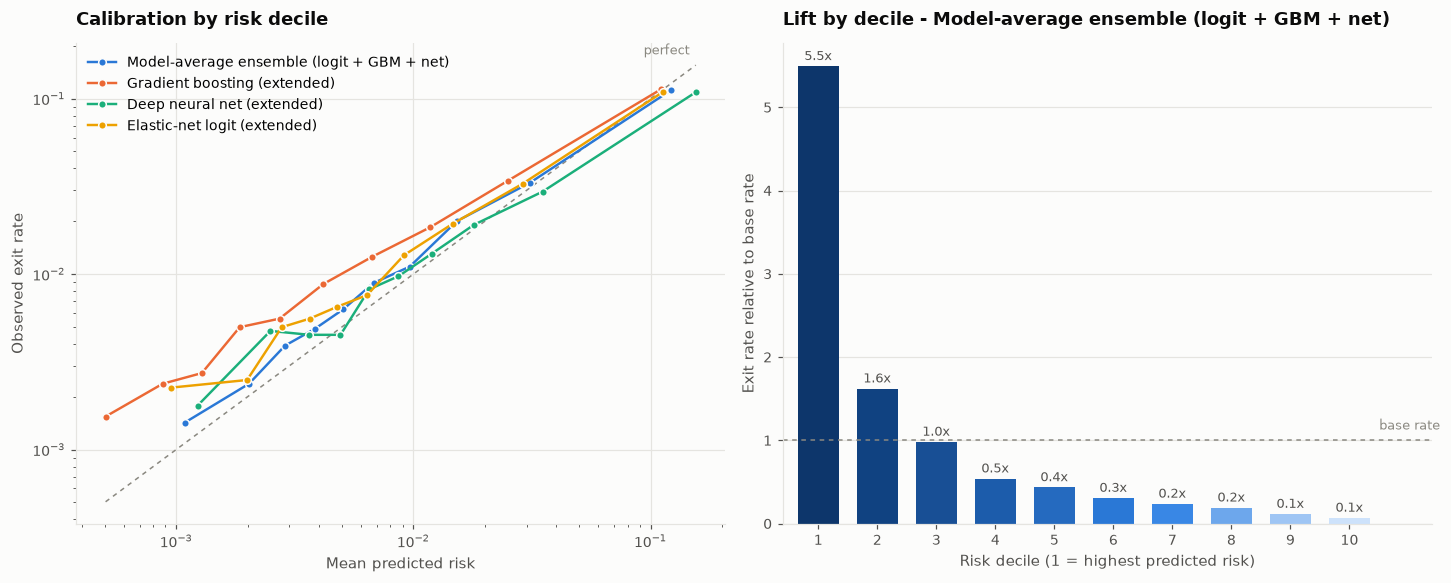

In [10]:
top_four = list(results.index[:4])
calibrations = {fitted[k].spec.label: calibration_table(y_test, fitted[k].risk(test))
                for k in top_four}

fig, axes = plots.plt.subplots(1, 2, figsize=(13.4, 5.4))
plots.plot_calibration(calibrations, ax=axes[0])
best = results.index[0]
lift = lift_table(y_test, fitted[best].risk(test))
plots.plot_decile_lift(lift, ax=axes[1], title=f"Lift by decile - {fitted[best].spec.label}")
fig.tight_layout();

In [11]:
lift.style.format({"n": "{:,.0f}", "n_events": "{:,.0f}", "event_rate": "{:.2%}",
                   "mean_predicted": "{:.2%}", "lift": "{:.2f}x",
                   "cumulative_recall": "{:.1%}"})

,n,n_events,event_rate,mean_predicted,lift,cumulative_recall
decile,,,,,,
1,"8,434",945,11.20%,12.24%,5.49x,54.9%
2,"8,434",279,3.31%,3.09%,1.62x,71.2%
3,"8,434",169,2.00%,1.53%,0.98x,81.0%
4,"8,434",93,1.10%,0.97%,0.54x,86.4%
5,"8,434",75,0.89%,0.68%,0.44x,90.8%
6,"8,433",53,0.63%,0.50%,0.31x,93.8%
7,"8,434",41,0.49%,0.38%,0.24x,96.2%
8,"8,434",33,0.39%,0.29%,0.19x,98.1%
9,"8,434",20,0.24%,0.20%,0.12x,99.3%


The top decile contains 945 of the 1,720 exits, 55% of them, at an 11.2%
realised rate against a 2.0% base. That is the ensemble, the top-ranked model on
average precision (the decile table always follows whichever model leads the
table above).

Calibration is where the ensemble earns its place. Its slope is 0.93, against
0.83 for gradient boosting alone in the calibration chart to the left: averaging
three probabilities averages away much of gradient boosting's over-dispersion.
The intercept is still negative, though (−0.19, against −0.28 for gradient
boosting), and the top decile slightly *over*-predicts (12.2% predicted against
11.2% realised). The Platt or isotonic recalibration layer earlier sections
called for is less urgent than for gradient boosting alone, but it is not
redundant, and one good summary statistic does not guarantee good calibration in
the range that matters most for triage.

## What the model relies on

Permutation importance on the **test** year, so it measures what the model
actually uses out of sample rather than what it fitted in sample. Correlated
features share credit and each looks weaker than it is; read this as "what would
I lose by losing this column", not as a causal decomposition.

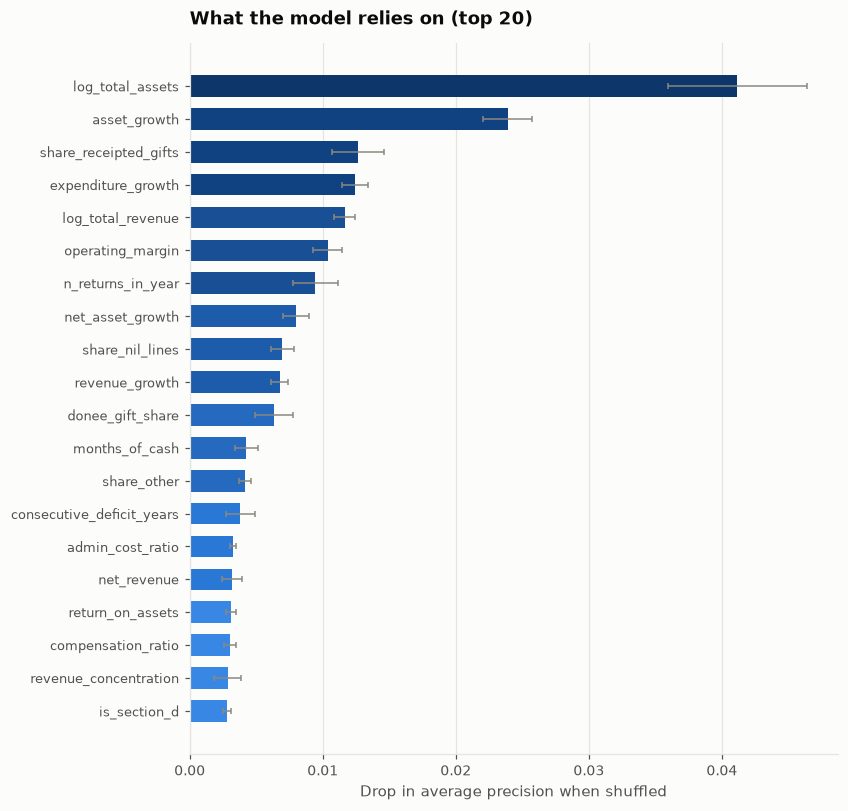

In [12]:
importance = pd.read_csv(config.TABLE_DIR / "exit_permutation_importance.csv")
fig, ax = plots.plt.subplots(figsize=(7.6, 8.4))
plots.plot_permutation_importance(importance, top_n=20, ax=ax);

Because the ensemble is the top-ranked model, this is its permutation
importance: how much each feature contributes across all three components
together, not gradient boosting's alone. Four things stand out.

**Size and its rate of change lead.** `log_total_assets` is far ahead of
everything else, with `asset_growth` second. Together they are the story the
Trussel (2002) size coefficient was pointing at.

**The classical ratios are supporting evidence.** `operating_margin` is the
highest of them, sixth. `admin_cost_ratio` (15th) and `revenue_concentration`
(19th) sit inside the top twenty; `equity_balance` (30th) and `debt_ratio`
(43rd) fall well outside it. Two HS ratios that are new to the feature set,
`net_revenue` (16th) and `return_on_assets` (17th), land beside them. None
displaces size as the dominant signal.

**Dynamics matter almost as much as levels.** Four of the top ten,
`asset_growth`, `expenditure_growth`, `net_asset_growth` and `revenue_growth`,
are year-on-year changes rather than levels. This is the clearest advantage the
panel gives us over the cross-sectional designs of the original studies: what a
charity's balance sheet is *doing* predicts deregistration better than what it
*is*.

**Reporting breadth, filing events and gift flows are genuinely predictive.**
`n_returns_in_year` ranks seventh and `share_nil_lines` ninth, both ahead of
every liquidity ratio, and neither is a financial ratio. `share_receipted_gifts`
(third) and `donee_gift_share` (eleventh) are a composition pair worth reading
together: how much of an organisation's revenue is receipted donations, and how
much of its spending is gifts passed on to other qualified donees. A charity
that is mostly a pass-through for other charities' fundraising looks different
from one raising money for its own programs, and apparently exits differently
too.

`share_nil_lines` needs reading carefully. A blank on a line the filer was asked
is a reported *zero*, not missing data, so this is not "incomplete filing
predicts failure". It is the share of asked lines a charity reports nothing on,
a measure of how few distinct activities it has. Reporting nil almost
everywhere is what dormancy looks like on a tax return.

`n_returns_in_year` is a filing *event*: two periods ending in the same year
means a year-end change, and a stub period is what a charity files on the way to
winding up or amalgamating.

## Deep learning, after Alam, Gao and Jones (2021)

{cite:t}`alam2021` compare a deep model against a **discrete-time hazard
model** — the standard panel-data workhorse in the failure literature — on
641,667 firm-months of North American listed companies. Their headline is
that the deep model identifies failures far better: sensitivity 93.71%
against 86.95%.

Three things about that comparison are worth carrying over carefully, because
two of them are easy to misread.

**Their headline number is sensitivity, not accuracy.** On overall accuracy the
hazard model actually *wins* (93.3% against 91.2%), as does specificity (93.53%
against 90.28%). The deep model trades false positives for caught failures. That
is a defensible trade — Alam et al. cite estimates that a missed failure costs
over 36 times a false alarm — but it is a threshold choice, not a uniform
improvement, and at their 21.5% failure rate those percentages behave very
differently from ours at 2.0%. We report ranking metrics instead, which do not
depend on where the threshold is put.

**Our benchmark is already a discrete hazard model.** A pooled logit over
charity-years predicting an event in the next period is exactly the
discrete-time hazard specification of {cite:t}`shumway2001` and
{cite:t}`hillegeist2004` that Alam et al. compare against. So the contest they
set up — deep model versus discrete hazard — is close to the one already
running in the table above.

**The architecture does not transplant; the discipline does.** Their network is
a GrNet operating on the Grassmann manifold, which needs a Riemannian autodiff
framework. What we take is the depth-with-narrowing shape (their blocks run
80 → 40 → 20) and the preprocessing the paper insists on — winsorise at the
1st/99th percentile, normalise feature by feature — because unlike gradient
boosting, neural networks are badly behaved on raw financial ratios with
unbounded tails. Both were already in our pipeline.

In [13]:
from charity_risk.models import build_mlp_pipeline, extended_features
from sklearn.model_selection import StratifiedKFold, cross_val_score

numeric, categorical = extended_features()
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=config.RANDOM_STATE)
grid = {
    "(80, 40, 20)  [Alam block sizes]": dict(hidden_layer_sizes=(80, 40, 20)),
    "(64, 32)": dict(hidden_layer_sizes=(64, 32)),
    "(256, 128, 64)": dict(hidden_layer_sizes=(256, 128, 64)),
    "(256, 128, 64) alpha=1e-2": dict(hidden_layer_sizes=(256, 128, 64), alpha=1e-2),
}
rows = []
for label, params in grid.items():
    pipeline = build_mlp_pipeline(numeric, categorical, **params)
    scores = cross_val_score(pipeline, train[numeric + categorical],
                             train["exit_next_year"], cv=cv, scoring="average_precision")
    rows.append({"architecture": label, "cv_average_precision": scores.mean(),
                 "cv_sd": scores.std()})
pd.DataFrame(rows).set_index("architecture").round(4)

,cv_average_precision,cv_sd
architecture,,
"(80, 40, 20) [Alam block sizes]",0.1895,0.0197
"(64, 32)",0.1846,0.0233
"(256, 128, 64)",0.1742,0.0281
"(256, 128, 64) alpha=1e-2",0.1742,0.0281


Compared on the **training year alone**: three-fold cross-validation, average
precision, the test year never consulted.

Every architecture tried lands within one standard deviation of every other.
With the current feature set Alam et al.'s block sizes score highest (0.190
against 0.174 for the 256-128-64 network the table reports), but that gap is
well inside the fold-to-fold spread, so the reported network is kept. The model
class matters here; its exact shape does not, which is worth knowing before
anyone spends a week on architecture search.

Two negative results worth recording:

* **Naive oversampling of the minority class made things markedly worse.** On
  the earlier 51-feature set it cut AUC to 0.734 against 0.832. Duplicating positives to address the 2% base rate
  distorts the probability scale the ranking metrics depend on. The model is
  fitted on the unbalanced data as it stands.
* **Honest selection costs some test-year average precision.** On the earlier
  51-feature set, the same architecture with the weaker penalty (`alpha=1e-4`)
  scored 0.185 on the test year against 0.174 for the cross-validated choice.
  We report the cross-validated one. Anyone comparing published deep-learning results against
  published benchmarks should ask which of the two protocols produced each
  number.

### Where the deep net lands

Third on average precision, behind gradient boosting and the ensemble, and
lower on ROC-AUC. Which metric you read changes its position, and that is the
interesting part.

On **average precision** it sits between the elastic-net logit and gradient
boosting (0.171 against 0.157 and 0.193), and the paired bootstraps below put
both gaps clear of zero. On **ROC-AUC** it falls *below* the logit (0.820
against 0.828) and well behind gradient boosting (0.844). So the deep model's
advantage over the linear one is concentrated where the positives are, not
spread across the ranking: the same pattern the Schedule 6 features showed in
`04-schedule-6-deep-dive`.

It does not overturn the ordering among the individually-fitted models: on this
data, at this sample size, gradient boosting still ranks better on both
metrics. That is the expected result for tabular data of this size, and it is
worth saying why rather than treating it as a surprise: Alam et al. have
641,667 observations and 79 features including market prices that move daily.
We have 84,344 annual observations of accounting lines. Deep models earn their
advantage on volume and on signal that is awkward to express as a ratio, and we
have neither in abundance.

Nor is it the best-calibrated of the three: its slope is 0.83, the same as
gradient boosting's, against 0.88 for the elastic-net logit. Calibration is what
matters if the score is going to be multiplied by a dollar amount rather than
just sorted.

In [14]:
dnn_vs_gbm = bootstrap_metric_difference(
    y_test, fitted["deep_neural_net"].risk(test), fitted["gradient_boosting"].risk(test),
    metric=average_precision_score, n_boot=500)
dnn_vs_logit = bootstrap_metric_difference(
    y_test, fitted["deep_neural_net"].risk(test), fitted["extended_logit"].risk(test),
    metric=average_precision_score, n_boot=500)

pd.DataFrame({
    "deep net - gradient boosting": dnn_vs_gbm,
    "deep net - elastic-net logit": dnn_vs_logit,
}).T[["difference", "ci_low", "ci_high", "p_worse"]].round(4)

,difference,ci_low,ci_high,p_worse
deep net - gradient boosting,-0.0215,-0.0333,-0.0098,1.0
deep net - elastic-net logit,0.0142,0.0043,0.0248,0.0


## Does combining help?

Three flexible models, three different error patterns: gradient boosting ranks
best; the elastic-net logit ranks lowest of the three but is the best calibrated;
the deep net sits between them on ranking and shares gradient boosting's
over-dispersion. Forecast combination ({cite:t}`bates1969`) asks the obvious
next question: does an equal-weight average of their predicted probabilities
beat the best of them individually? `ensemble_blend` in the table at the top of
this notebook is exactly that average.

In [15]:
blend_vs_gbm_ap = bootstrap_metric_difference(
    y_test, fitted["ensemble_blend"].risk(test), fitted["gradient_boosting"].risk(test),
    metric=average_precision_score, n_boot=500)
blend_vs_gbm_auc = bootstrap_metric_difference(
    y_test, fitted["ensemble_blend"].risk(test), fitted["gradient_boosting"].risk(test),
    metric=roc_auc_score, n_boot=500)

pd.DataFrame({
    "average precision": blend_vs_gbm_ap,
    "ROC-AUC": blend_vs_gbm_auc,
}).T[["difference", "ci_low", "ci_high", "p_worse"]].round(4)

,difference,ci_low,ci_high,p_worse
average precision,0.0030,-0.0052,0.0116,0.250
ROC-AUC,-0.0035,-0.0069,-0.0001,0.976


On ranking, no. The blend edges out gradient boosting on average precision
(0.196 against 0.193), but the paired-bootstrap interval on that gain, +0.003
[−0.005, +0.012], spans zero. On ROC-AUC it is slightly *behind* (0.840 against
0.844; −0.0035, [−0.0069, −0.0001]). Combining does not sharpen the ranking
beyond what gradient boosting already achieves.

On calibration, yes. The blend's slope is 0.93 against gradient boosting's 0.83,
and its intercept −0.19 against −0.28: closer to the (1, 0) of a perfectly
calibrated score on both. That is not a coincidence: averaging three probability
estimates that are each somewhat over- or under-dispersed pulls the composite
back toward the middle, the same arithmetic that makes averaging forecasts a
decades-old habit in economics. For a regulator who wants to turn the score into
an expected number of exits rather than just a ranking, the ensemble is the
more usable model, at the cost of running, and explaining, three models instead
of one. For a ranking alone, gradient boosting does as well on its own.

## The other outcome: three-year net-asset decline

The benchmark models were built for this outcome, so it is the fairer test of
them. Fitted on the 2019 cohort (resolved 2022), tested on 2020 (resolved 2023).
Results are read from the pipeline run.

In [16]:
vulnerability = pd.read_csv(config.TABLE_DIR / "vulnerability_model_comparison.csv",
                            index_col=0)
vulnerability[["label", "roc_auc", "average_precision", "brier_skill",
               "lift_top5pct", "calibration_slope"]].round(3)

,label,roc_auc,average_precision,brier_skill,lift_top5pct,calibration_slope
model,,,,,,
gradient_boosting,Gradient boosting (extended),0.702,0.360,0.079,2.370,0.942
ensemble_blend,Model-average ensemble (logit + GBM + net),0.697,0.350,0.074,2.206,1.067
deep_neural_net,Deep neural net (extended),0.688,0.336,0.067,2.070,0.886
extended_logit,Elastic-net logit (extended),0.667,0.321,0.051,1.953,0.946
trussel_2002,Trussel logit (ratios + size + sector),0.655,0.312,0.042,1.918,1.032
size_only,Size only (log revenue),0.611,0.270,0.014,1.630,0.899
greenlee_trussel_2000,Greenlee-Trussel logit (4 TC ratios),0.570,0.262,0.010,1.867,0.889
hs_index_flags,HS index (flags),0.543,0.230,0.002,1.445,0.954
tuckman_chang_1991,Tuckman-Chang score (0-4),0.557,0.228,0.005,1.482,0.914


The top four keep their relative order (the extended models beat Trussel
(2002), which beats Greenlee-Trussel (2000)), but the ordering does not survive
completely: the size-only baseline and Greenlee-Trussel swap places. On exit,
Greenlee-Trussel edges out size-only (average precision 0.094 against 0.081);
on vulnerability the size-only baseline is ahead (0.270 against 0.262). Four
ratios plus no size control beats one variable at predicting deregistration and
loses to it at predicting a net-asset decline, a reminder that "the ordering
survives" is doing real work as a claim and should be checked, not assumed,
whenever the outcome changes.

The HS index does worse here than on exit, relative to everything else. Both
forms finish at the bottom of the table with the Tuckman-Chang count, and the
percentile form has the lowest average precision of all (0.221 against 0.228 for
the count) and a Brier skill just below zero. An index whose dimensions are
weighted equally rather than fitted has no way to lean on the ratios that matter
for a different outcome.

Beyond that, every model is weaker in absolute terms here: the best AUC is
0.702 against 0.844 on exit. Three-year net-asset decline is simply harder to
predict: it is a threshold on a noisy continuous quantity, 20% of charity-years
cross it, and much of the crossing is ordinary endowment volatility rather than
distress.

That is worth stating plainly, because it cuts against a natural reading of the
literature. The classics do not underperform here because they are bad models.
They underperform because the outcome they were designed around is closer to
noise than the outcome we actually care about. The Canadian filing record gives
us a cleaner target, and every model does better on it.

## A Bayesian alternative

Gradient boosting ranks best and says nothing about uncertainty. A hierarchical
logistic model with partially-pooled intercepts for charity category and province
answers two questions the point-estimate models cannot: how much exit risk is
*structural* (sector, geography) rather than organisational, and how confident we
should be about any single charity's score.

Fitted by ADVI — minutes rather than hours. `method="nuts"` gives the honest
posterior at considerably more expense.

In [17]:
from charity_risk.hierarchical import (
    HIERARCHICAL_FEATURES, fit_hierarchical, group_effect_table,
)
from sklearn.metrics import average_precision_score, roc_auc_score

hier_columns = list(HIERARCHICAL_FEATURES) + ["category_desc", "province", "exit_next_year"]
hier_frame = load_dataset(years=[config.TRAIN_YEAR, config.TEST_YEAR], columns=hier_columns)
hier_train, hier_test = exit_split(hier_frame)

hier = fit_hierarchical(hier_train, advi_iterations=20_000)
hier_pred = hier.predict(hier_test)
print(f"AUC {roc_auc_score(hier_test['exit_next_year'], hier_pred['risk_mean']):.3f}   "
      f"AP {average_precision_score(hier_test['exit_next_year'], hier_pred['risk_mean']):.3f}")

g++ not available, if using conda: `conda install gxx`


Finished [100%]: Average Loss = 6,531.2


AUC 0.803   AP 0.102


Placed against the ladder above, this is a middling result: AUC 0.803 and
average precision 0.102 sit *below* the plain Trussel (2002) logit's 0.807 and
0.111 — despite the hierarchical model having more than twice as many
predictors (13 against 6) and a variance-pooling structure the flat logit
lacks. That is not a contradiction of anything claimed for it. Two choices made
for interpretability's sake cost ranking sharpness on the way in: the ADVI fit
is a variational point approximation rather than an exact posterior, and
missing values here are mean-imputed rather than getting the
imputation-with-indicator treatment the scikit-learn pipelines use, because a
missing-indicator interaction would muddy the coefficients this model exists
to report. This model is not competing for the top of the table — its purpose
is the variance decomposition below, which no point-estimate model in the
ladder can produce at any accuracy.

In [18]:
import arviz as az

az.summary(hier.idata, var_names=["alpha", "sigma_category", "sigma_province"],
           ci_prob=0.9)[["mean", "sd"]].round(3)

,mean,sd
alpha,-4.596,0.056
sigma_category,0.284,0.042
sigma_province,0.215,0.048


`sigma_category` ≈ 0.28 and `sigma_province` ≈ 0.22 on the log-odds scale. Both
are small: moving from an average category to one a full standard deviation
riskier multiplies the odds of exit by about 1.3, against the roughly 20-fold
range the organisational predictors span.

**Exit risk in the Canadian charity sector is overwhelmingly organisation-specific,
not sectoral or geographic.** That is a substantive finding, and it argues against
the sector fixed effects that Trussel (2002) added — they are doing very little
work, and in our comparison the Trussel specification's advantage over
Greenlee-Trussel comes from the size control and the debt ratio, not from the
sector dummies.

In [19]:
category_effects = group_effect_table(hier, "category")
pd.concat([category_effects.head(6), category_effects.tail(6)])[["mean", "sd"]].round(3)

,mean,sd
Animal Welfare,0.520,0.197
Educational organizations not elsewhere categorized,0.515,0.180
Organizations Relieving Poverty,0.122,0.083
Foundations Advancing Education,0.102,0.165
Teaching Institutions,0.099,0.143
Complementary or Alternative Health Care,0.091,0.284
Arts,-0.175,0.149
Environment,-0.257,0.238
Foundations,-0.275,0.096
Other Religions,-0.337,0.219


In [20]:
coefficients = az.summary(hier.idata, var_names=["beta"], ci_prob=0.9)
coefficients.index = list(HIERARCHICAL_FEATURES)
coefficients[["mean", "sd"]].sort_values("mean").round(3)

,mean,sd
log_total_revenue,-0.816,0.035
equity_balance,-0.24,0.037
donation_dependence,-0.214,0.039
operating_margin,-0.167,0.027
share_government,-0.096,0.052
revenue_growth,0.021,0.031
log_age,0.033,0.036
debt_ratio,0.042,0.03
admin_cost_ratio,0.05,0.033
months_of_cash,0.081,0.036


Most signs match the classical fits. Size dominates by a factor of three over
anything else; a stronger equity balance, a healthier operating margin, and
greater reliance on donations or on government funding all lower the risk.
Revenue concentration, consecutive deficit years, and filing on the short form
all raise it — and the administrative cost ratio is positive here too, the same
direction it took in the exit logit in `02-features-and-benchmarks` and the
opposite of what Tuckman and Chang assumed.

Two coefficients are worth not glossing over.

**Age does essentially nothing** (0.03 ± 0.04) once revenue is in the model, even
though the flexible models still draw on `log_age` (21st in the ensemble's
importance table). Age and size are correlated, and in a linear model size
absorbs it; the tree model finds non-linear age effects a single coefficient
cannot express.

**Months of cash is mildly *positive*** (0.08 ± 0.04) — more cash relative to
spending associates with slightly *higher* exit risk. That is not what a liquidity
measure should do, and the likely explanation is conditioning: among charities of
the same size, one holding most of its assets as cash is often one that has
stopped operating and is sitting on a balance to be distributed. It is a caution
against reading any single coefficient here as an effect.

In [21]:
top_categories = group_effect_table(hier, "category").head(4)
print("Categories with the highest baseline exit hazard, holding financials fixed:")
top_categories[["mean", "sd"]].round(3)

Categories with the highest baseline exit hazard, holding financials fixed:


,mean,sd
Animal Welfare,0.52,0.197
Educational organizations not elsewhere categorized,0.515,0.18
Organizations Relieving Poverty,0.122,0.083
Foundations Advancing Education,0.102,0.165


Animal welfare and general educational organisations carry the highest baseline
hazard, both around +0.5 log-odds — roughly a 1.7-fold increase in odds relative
to the sector average. These are the largest category effects in the model, and
they are still an order of magnitude smaller than the spread the size coefficient
generates.

## Scoring the current cohort

The 2022 cohort has features but no trustworthy label — only one later year
exists, which is not enough to separate a permanent exit from a late filing. That
is precisely the population a supervisor would be triaging, so it is what the
model is put to work on.

In [22]:
watchlist = pd.read_csv(config.TABLE_DIR / "watchlist_2022.csv")
print(f"{len(watchlist):,} highest-risk organisations of "
      f"{len(scoring_frame(frame, config.SCORE_YEAR)):,} in the 2022 cohort")

display_columns = ["rank", "province", "charity_type", "total_revenue", "net_assets",
                   "operating_margin", "consecutive_deficit_years", "is_section_d", "risk"]
watchlist[display_columns].head(15).style.format({
    "total_revenue": "${:,.0f}", "net_assets": "${:,.0f}",
    "operating_margin": "{:.2f}", "risk": "{:.1%}",
})

500 highest-risk organisations of 84,092 in the 2022 cohort


,rank,province,charity_type,total_revenue,net_assets,operating_margin,consecutive_deficit_years,is_section_d,risk
0,1,ON,Other Purposes Beneficial to the Community,$151,$0,-811.16,1.000000,1,90.7%
1,2,ON,Advancement of Religion,$79,$0,-72.15,1.000000,1,88.4%
2,3,ON,Other Purposes Beneficial to the Community,"$6,542",$0,-14.50,2.000000,1,83.5%
3,4,BC,Advancement of Education,$0,$0,nan,0.000000,1,81.2%
4,5,QC,Relief of Poverty,$0,$285,nan,0.000000,1,79.3%
5,6,ON,Other Purposes Beneficial to the Community,$0,$0,nan,0.000000,1,77.0%
6,7,ON,Other Purposes Beneficial to the Community,$0,$0,nan,0.000000,1,76.1%
7,8,BC,Other Purposes Beneficial to the Community,$0,$0,nan,0.000000,1,75.5%
8,9,ON,Other Purposes Beneficial to the Community,$0,$0,nan,0.000000,1,74.2%
9,10,AB,Advancement of Religion,$5,$1,-25071.60,4.000000,1,73.6%


In [23]:
cohort = scoring_frame(frame, config.SCORE_YEAR)
scored = cohort.assign(risk=fitted[best].risk(cohort))
pd.DataFrame({
    "n": scored.groupby(pd.qcut(scored["risk"], 10, labels=range(1, 11)), observed=True).size(),
    "mean_risk": scored.groupby(pd.qcut(scored["risk"], 10, labels=range(1, 11)),
                                observed=True)["risk"].mean(),
    "median_revenue": scored.groupby(pd.qcut(scored["risk"], 10, labels=range(1, 11)),
                                     observed=True)["total_revenue"].median(),
}).iloc[::-1].style.format({"n": "{:,.0f}", "mean_risk": "{:.2%}",
                            "median_revenue": "${:,.0f}"})

,n,mean_risk,median_revenue
risk,,,
10,"8,410",11.85%,$0
9,"8,409",2.86%,"$9,278"
8,"8,409",1.50%,"$29,695"
7,"8,409",0.99%,"$61,728"
6,"8,409",0.71%,"$104,404"
5,"8,409",0.54%,"$146,203"
4,"8,409",0.41%,"$196,155"
3,"8,409",0.31%,"$253,750"
2,"8,409",0.22%,"$399,968"


## What this does and does not establish

**Established.**

* The Tuckman-Chang measures still carry signal in Canada thirty years on and in
  the direction their authors predicted — a four-flag charity exits at six times
  the base rate. But the 0-4 discretisation throws most of that signal away
  (AUC 0.587), and 80% of the register lands in two indistinguishable buckets.
* Trussel (2002) beats Greenlee-Trussel (2000) out of sample, reproducing the
  literature's own progression on independent data.
* **The HS index beats the Tuckman-Chang count, but not size alone.** With no
  fitted weight it gains 0.078 AUC and 0.017 average precision on the count,
  both intervals clear of zero, and halves the review needed to catch half of
  all exits (22.6% of the register against 44.3%). It stays below the
  size-only baseline and every fitted model on exit, and drops to the bottom
  of the table on the net-asset-decline outcome.
* **The administrative cost ratio points the wrong way for exit.** Higher
  administrative spending as a share of expenditure predicts deregistration, in
  both the classical logit and the hierarchical model. Tuckman and Chang's slack
  argument — that lean overhead means nothing left to cut — does not hold for
  this outcome in this population, and their scoring rule flags the wrong tail
  because of it.
* A model with the same underlying financial information plus size, age,
  dynamics and filing behaviour roughly doubles average precision over the best
  classical benchmark (0.193 against 0.111) and lifts top-1% precision from 9.2x
  to 17.2x.
* **A deep network is competitive but not superior.** Following Alam, Gao and
  Jones (2021), a three-layer network is clearly ahead of every classical
  benchmark and sits between the elastic-net logit and gradient boosting on
  average precision, but falls below the logit on AUC. The finding that deep learning beats traditional panel models does not
  reproduce here, and the sample-size gap (84,000 charity-years against 641,667
  firm-months) is the most likely reason.
* **Averaging the three flexible models improves calibration, not ranking.**
  The model-average ensemble's average precision (0.196) is indistinguishable
  from gradient boosting's (0.193; interval [−0.005, +0.012]), and its AUC is
  slightly lower. Its calibration is better: slope 0.93 and intercept −0.19,
  against 0.83 and −0.28 for gradient boosting alone. That is a cheap gain,
  since it needs no new features and no new model class, only three models
  already being fitted anyway.
* Exit risk is organisation-specific. Sector and province explain little once
  organisational characteristics are controlled for.

**Not established, and it would be wrong to claim otherwise.**

* *Exit is not insolvency.* Deregistration bundles collapse together with solvent
  wind-ups, amalgamations and revocations for failure to file. Linking to the
  CRA's published revocation reasons would separate these, and is the single
  highest-value extension available.
* *One training year, one test year.* The five-year window with a two-year
  lookahead requirement leaves exactly one clean out-of-time comparison. The
  ordering is stable across both outcomes, which is reassuring, but the point
  estimates carry more sampling variation than a single bootstrap interval
  suggests.
* *2020 and 2021 are pandemic years.* The training cohort's finances were shaped
  by emergency wage subsidies and cancelled fundraising. Relationships fitted
  there may not transfer to an ordinary year.
* *`share_nil_lines` measures inactivity, not financial health.* A blank on a
  line the filer was asked is a reported zero, so this counts how few kinds of
  revenue and expenditure a charity has, not how carelessly it files. It earns
  its high ranking because dormancy looks like nil almost everywhere on a
  tax return. A model used to *diagnose* financial distress rather than to
  *triage* should read it as a proxy for having stopped operating.
* *No causal claim anywhere.* Nothing here says that raising administrative
  spending would reduce exit risk. These are screening associations.
* *The HS index is not tuned to this outcome.* Its five dimensions are weighted
  equally and its ratio directions are fixed in advance, including the low-tail
  reading of the administrative cost ratio that this notebook and
  `02-features-and-benchmarks` find runs the wrong way on exit. Its rows in the
  table test the specification as written; `06-hs-risk-index` measures what
  that one direction costs.
* *The deep model is not the one Alam et al. built.* Theirs is a GrNet over a
  Grassmann-manifold representation of each firm's full month-by-month history;
  ours is a multilayer perceptron on a single year's features plus one-year
  deltas. Their central contribution — a fixed-size encoding of variable-length
  panel histories — cannot be evaluated here: it needs a subspace dimension
  *d* no larger than the shortest history, and our training year has two annual
  observations to work with, against their minimum of nine monthly ones. That
  comparison becomes possible as the panel lengthens, and it is the most
  interesting untested idea in this project.
* *The ensemble does not rank better than gradient boosting alone.* A
  supervisor who only cares about the ordering of the register should prefer
  the single, cheaper gradient-boosting model; the ensemble's case is
  calibration, not discrimination, and which one matters depends on what the
  score is used for.